# FX Carry Monitor

Tracks spot GBP/USD, EUR/USD and USD/JPY, alongside an approximate short-rate-differential carry proxy between the US and the UK, and the US and the euro area.

### GBP/USD and EUR/USD spot

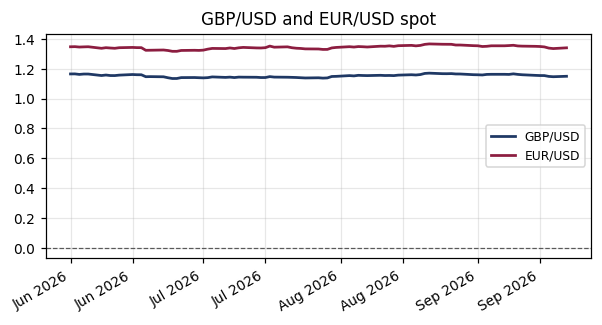

In [1]:
# chart

*Source: ECB reference rates, via the Frankfurter API*

**Code:**
```python
fx["GBPUSD"] = 1 / fx["gbp_usd_perusd"]
fx["EURUSD"] = 1 / fx["eur_usd_perusd"]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(fx["date"], fx["GBPUSD"], color="#1F3864", label="GBP/USD")
ax.plot(fx["date"], fx["EURUSD"], color="#8C1D40", label="EUR/USD")
ax.legend()
```

**What this shows:**

Both pairs quote how many dollars one pound or one euro buys, so when they move together it's usually a dollar story rather than a sterling- or euro-specific one — broad dollar strength (often tied to relatively higher US yields drawing in capital) pushes both down together, and broad dollar weakness lifts both. When the two diverge, that's the signal to look for something specific to the UK or euro area — a Bank of England or ECB decision, a UK fiscal event, or European political news — rather than a US-driven move.

### USD/JPY spot

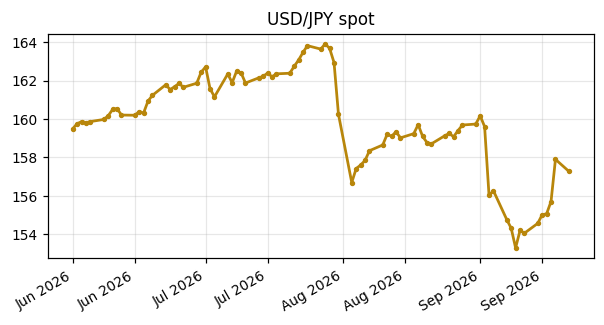

In [1]:
# chart

*Source: ECB reference rates, via the Frankfurter API*

**Code:**
```python
fx["USDJPY"] = fx["jpy_usd_perusd"]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(fx["date"], fx["USDJPY"], color="#B8860B", lw=1.8, marker="o", markersize=2.5)
```

**What this shows:**

USD/JPY behaves differently from the two pairs above because Japan has run near-zero interest rates for so long that the yen is the classic 'funding currency' for carry trades — investors borrow cheaply in yen and invest the proceeds in higher-yielding assets elsewhere, which structurally weakens the yen (pushes USD/JPY up) as long as that trade stays attractive. The pair tends to move sharply, not gradually, when that trade unwinds — typically around moments that make the funding side suddenly look riskier, such as a hawkish Fed surprise that widens the rate gap further, or any signal the Bank of Japan might finally raise rates.

### Short-rate differential (a carry proxy)

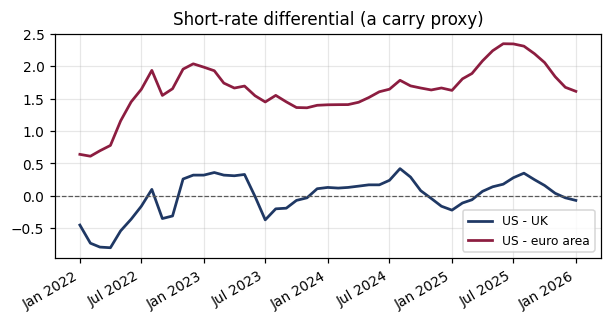

In [1]:
# chart

*Source: FRED (FEDFUNDS) and OECD 3-month interbank rates, mirrored on FRED*

**Code:**
```python
carry["us_uk_diff"] = carry["fed_funds_rate"] - carry["uk_3m_interbank_rate"]
carry["us_ea_diff"] = carry["fed_funds_rate"] - carry["ea_3m_interbank_rate"]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(carry["date"], carry["us_uk_diff"], color="#1F3864", label="US - UK")
ax.plot(carry["date"], carry["us_ea_diff"], color="#8C1D40", label="US - euro area")
ax.legend()
```

**What this shows:**

This is the logic behind a carry trade made concrete: the wider the gap between US short rates and UK or euro-area short rates, the more an investor earns simply by holding dollar-denominated short-term assets funded in pounds or euros, before any view on the exchange rate itself. A widening differential tends to support the dollar for as long as it persists, but it's also the exact kind of position that unwinds fast if US rate expectations reverse suddenly — the gap closing quickly is usually accompanied by a sharp countertrend move in the currency pair itself, not a gradual one.

## Caveats on the data behind this notebook

**FX carry is approximated with realised short-rate differentials**, not forward-implied points or covered-interest-parity carry — no free forward-FX source was available without a paid data key, so this is a simplified stand-in for what a real carry desk would actually calculate.

**The short-rate differential chart only covers the months where both the US Fed funds series and the UK/euro-area interbank series overlap** — where one series runs ahead of or behind the other, that period is simply excluded from the differential rather than filled in.